<a href="https://colab.research.google.com/github/LiQuinChing/25-26J-522/blob/Detection-of-Arrhythmia-vihara/KNNandCNNLSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


no need to run again files already saved

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Source of Data
# https://www.kaggle.com/datasets/shayanfazeli/heartbeat

# Update these paths to match your exact Google Drive folder structure
train_path = "/content/drive/MyDrive/Datasets/mitbih_train.csv"
test_path = "/content/drive/MyDrive/Datasets/mitbih_test.csv"

# Load Data
train_df = pd.read_csv(train_path, header=None)
test_df = pd.read_csv(test_path, header=None)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

X_train_full = train_df.iloc[:, :-1].values
y_train_full = train_df.iloc[:, -1].values.astype(int)

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

# Split train  train/val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    stratify=y_train_full,
    random_state=42
)

print(f"\n{'='*60}")
print("Dataset Statistics")
print('='*60)
print(f"\nTrain: {len(X_train)} samples")
print(f"Val: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

print(f"\nClass distribution:")
print(f"{'Class':<10} {'Train':<10} {'Val':<10} {'Test':<10}")
print('-'*60)
for i in range(5):
    train_count = (y_train == i).sum()
    val_count = (y_val == i).sum()
    test_count = (y_test == i).sum()
    print(f"{i:<10} {train_count:<10} {val_count:<10} {test_count:<10}")

# Reshape for CNN (187 timesteps, 1 channel)
X_train = X_train.reshape(-1, 187, 1)
X_val = X_val.reshape(-1, 187, 1)
X_test = X_test.reshape(-1, 187, 1)

print(f"\nReshaped data:")
print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

import os
import numpy as np
from google.colab import drive

# 2. Define the path where you want to save it in your Drive
# Change 'Datasets/my_numpy_data' to whatever folder name you prefer
save_dir = '/content/drive/MyDrive/Datasets/my_numpy_data'

# 3. Create the folder in your Google Drive if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

# 4. Save the files to that specific Google Drive path
np.save(os.path.join(save_dir, 'X_train.npy'), X_train)
np.save(os.path.join(save_dir, 'y_train.npy'), y_train)
np.save(os.path.join(save_dir, 'X_val.npy'), X_val)
np.save(os.path.join(save_dir, 'y_val.npy'), y_val)
np.save(os.path.join(save_dir, 'X_test.npy'), X_test)
np.save(os.path.join(save_dir, 'y_test.npy'), y_test)

print(f"\n✓ Data successfully saved to Google Drive at: {save_dir}")

Train shape: (87554, 188)
Test shape: (21892, 188)

Dataset Statistics

Train: 74420 samples
Val: 13134 samples
Test: 21892 samples

Class distribution:
Class      Train      Val        Test      
------------------------------------------------------------
0          61600      10871      18118     
1          1889       334        556       
2          4920       868        1448      
3          545        96         162       
4          5466       965        1608      

Reshaped data:
X_train: (74420, 187, 1)
X_val: (13134, 187, 1)
X_test: (21892, 187, 1)

✓ Data successfully saved to Google Drive at: /content/drive/MyDrive/Datasets/my_numpy_data


KNN model training

In [ ]:
import os
import numpy as np
import joblib
import time

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

data_dir = '/content/drive/MyDrive/Datasets/my_numpy_data'

# Create a new folder to save the trained model and results
save_dir = '/content/drive/MyDrive/Datasets/knn_results'
os.makedirs(save_dir, exist_ok=True)

# Load data_old
# 3. Load data from Google Drive
print("Loading data from Google Drive...")
X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

#Reshape for KNN
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Normalize
print("\nScaling data...")
scaler = RobustScaler() # StandardScaler() , MinMaxScaler() , RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler to Drive (you will need this if you want to predict on new data later!)
scaler_path = os.path.join(save_dir, 'robust_scaler.pkl')
joblib.dump(scaler, scaler_path)
print(f"✓ Scaler saved to {scaler_path}")

# Train KNN
print("\n🤖 Training KNN...")
start_time = time.time()
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan') # euclidean , manhattan , cosine , minkowski
knn.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

y_pred = knn.predict(X_test_scaled)

# Save the trained KNN model to Drive
model_path = os.path.join(save_dir, 'knn_model.pkl')
joblib.dump(knn, model_path)
print(f"✓ Model saved to {model_path}")

# Save the trained KNN model to Drive
model_path = os.path.join(save_dir, 'knn_model.pkl')
joblib.dump(knn, model_path)
print(f"✓ Model saved to {model_path}")

# 6. Predict & Metrics
print("\nPredicting on test set...")
y_pred = knn.predict(X_test_scaled)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')

print(f"\n✅ RESULTS:")
print(f"   Training time: {train_time:.2f}s")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   F1-Score (weighted): {f1_weighted:.4f}")
print(f"   F1-Score (macro): {f1_macro:.4f}")

# 8. Save the printed results to a text file in Google Drive
results_file = os.path.join(save_dir, 'knn_evaluation_results.txt')
with open(results_file, 'w') as f:
    f.write(results_text)

print("\n📋 Per-class report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal', 'Supraventr', 'Ventricular', 'Fusion', 'Unknown']))

# 7. Format the results and print them
results_text = f"""
✅ RESULTS:
   Training time: {train_time:.2f}s
   Accuracy: {accuracy:.4f}
   F1-Score (weighted): {f1_weighted:.4f}
   F1-Score (macro): {f1_macro:.4f}

📋 Per-class report:
{report}
"""
print(results_text)

print(f"\n✓ All results successfully saved to: {save_dir}")


Loading data from Google Drive...
Train: (74420, 187), Test: (21892, 187)

Scaling data...
✓ Scaler saved to /content/drive/MyDrive/Datasets/knn_results/robust_scaler.pkl

🤖 Training KNN...
✓ Model saved to /content/drive/MyDrive/Datasets/knn_results/knn_model.pkl
✓ Model saved to /content/drive/MyDrive/Datasets/knn_results/knn_model.pkl

Predicting on test set...

✅ RESULTS:
   Training time: 0.06s
   Accuracy: 0.9751
   F1-Score (weighted): 0.9740
   F1-Score (macro): 0.8710


NameError: name 'results_text' is not defined

In [ ]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
f1_macro = f1_score(y_test, y_pred, average='macro')
report = classification_report(y_test, y_pred,
                               target_names=['Normal', 'Supraventr', 'Ventricular', 'Fusion', 'Unknown'])

# 7. Format ALL the results into a single text variable FIRST
results_text = f"""
✅ RESULTS:
   Training time: {train_time:.2f}s
   Accuracy: {accuracy:.4f}
   F1-Score (weighted): {f1_weighted:.4f}
   F1-Score (macro): {f1_macro:.4f}

📋 Per-class report:
{report}
"""

# Now print it to the screen
print(results_text)

# 8. Save that exact text variable to the file in Google Drive
results_file = os.path.join(save_dir, 'knn_evaluation_results.txt')
with open(results_file, 'w') as f:
    f.write(results_text)

print(f"\n✓ All results successfully saved to: {save_dir}")


✅ RESULTS:
   Training time: 0.06s
   Accuracy: 0.9751
   F1-Score (weighted): 0.9740
   F1-Score (macro): 0.8710

📋 Per-class report:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99     18118
  Supraventr       0.90      0.65      0.76       556
 Ventricular       0.94      0.91      0.92      1448
      Fusion       0.79      0.64      0.71       162
     Unknown       0.99      0.96      0.98      1608

    accuracy                           0.98     21892
   macro avg       0.92      0.83      0.87     21892
weighted avg       0.97      0.98      0.97     21892



✓ All results successfully saved to: /content/drive/MyDrive/Datasets/knn_results


now lets see hoe it performs on the cnn-lstm model

In [ ]:
# ================== 0. IMPORTS ==================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os


# Define your Google Drive paths
data_dir = '/content/drive/MyDrive/Datasets/my_numpy_data'  # Where your .npy files are
save_dir = '/content/drive/MyDrive/Datasets/ecg_dl_results'  # Where to save the new model/plots
models_dir = os.path.join(save_dir, 'models')
results_dir = os.path.join(save_dir, 'results')

# ================== 1. LOAD DATA ==================
print("Loading data...")
X_train = np.load(os.path.join(data_dir, 'X_train.npy'))
y_train = np.load(os.path.join(data_dir, 'y_train.npy'))
X_val = np.load(os.path.join(data_dir, 'X_val.npy'))
y_val = np.load(os.path.join(data_dir, 'y_val.npy'))
X_test = np.load(os.path.join(data_dir, 'X_test.npy'))
y_test = np.load(os.path.join(data_dir, 'y_test.npy'))

print(f"Original Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Original class distribution: {np.bincount(y_train)}")

# ================== 1.2 ADD NORMALIZATION ==================
print("\n" + "=" * 60)
print("NORMALIZING DATA")
print("=" * 60)

# Fit scaler on training data
scaler = StandardScaler()
X_train_flat = X_train.reshape(-1, 187)
X_train_normalized = scaler.fit_transform(X_train_flat).reshape(-1, 1, 187)

# Transform val and test using training statistics
X_val_normalized = scaler.transform(X_val.reshape(-1, 187)).reshape(-1, 1, 187)
X_test_normalized = scaler.transform(X_test.reshape(-1, 187)).reshape(-1, 1, 187)

# Save scaler for inference
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.pkl')

# Save scaler for inference
os.makedirs(models_dir, exist_ok=True)
scaler_path = os.path.join(models_dir, 'scaler.pkl')
joblib.dump(scaler, scaler_path)

print(f"✓ Scaler saved to '{scaler_path}'")

print(f"✓ Scaler saved to 'models/scaler.pkl'")
print(f"\nNormalization statistics:")
print(f"  Mean: {scaler.mean_[0]:.4f}")
print(f"  Std: {scaler.scale_[0]:.4f}")

print(f"\nBefore normalization - Min: {X_train.min():.4f}, Max: {X_train.max():.4f}")
print(f"After normalization  - Min: {X_train_normalized.min():.4f}, Max: {X_train_normalized.max():.4f}")

X_train = X_train_normalized
X_val = X_val_normalized
X_test = X_test_normalized


# ================== 1.5 AGGRESSIVE DATA AUGMENTATION ==================
def augment_ecg_aggressive(X, y, target_class, n_augment):
    """More aggressive augmentation with multiple techniques"""
    class_mask = (y == target_class)
    class_samples = X[class_mask]
    augmented_X = []
    augmented_y = []

    for _ in range(n_augment):
        for sample in class_samples:
            sample_flat = sample.squeeze()
            aug_type = np.random.randint(0, 4)

            if aug_type == 0:
                alpha = np.random.uniform(0.85, 1.15)
                new_length = int(187 * alpha)
                warped = np.interp(np.linspace(0, 187, new_length), np.arange(187), sample_flat)
                if len(warped) < 187:
                    warped = np.pad(warped, (0, 187 - len(warped)), mode='edge')
                else:
                    warped = warped[:187]
                augmented = warped

            elif aug_type == 1:
                start = np.random.randint(0, 10)
                sliced = np.roll(sample_flat, -start)
                noise = np.random.normal(0, 0.04, 187)
                augmented = sliced + noise

            elif aug_type == 2:
                smooth = np.random.uniform(0.5, 2.0, 187)
                smooth = np.convolve(smooth, np.ones(10) / 10, mode='same')
                augmented = sample_flat * smooth

            else:
                alpha = np.random.uniform(0.9, 1.1)
                new_length = int(187 * alpha)
                warped = np.interp(np.linspace(0, 187, new_length), np.arange(187), sample_flat)
                if len(warped) < 187:
                    warped = np.pad(warped, (0, 187 - len(warped)), mode='edge')
                else:
                    warped = warped[:187]
                noise = np.random.normal(0, 0.03, 187)
                scale = np.random.uniform(0.9, 1.1)
                augmented = (warped + noise) * scale

            augmented_X.append(augmented.reshape(1, 187))
            augmented_y.append(target_class)

    return np.array(augmented_X), np.array(augmented_y)


print("\nPerforming data augmentation...")
aug_X_list, aug_y_list = [X_train], [y_train]

aug_X, aug_y = augment_ecg_aggressive(X_train, y_train, target_class=1, n_augment=6)
aug_X_list.append(aug_X)
aug_y_list.append(aug_y)
print(f" Supraventricular: +{len(aug_X)} samples")

aug_X, aug_y = augment_ecg_aggressive(X_train, y_train, target_class=3, n_augment=15)
aug_X_list.append(aug_X)
aug_y_list.append(aug_y)
print(f" Fusion: +{len(aug_X)} samples")

aug_X, aug_y = augment_ecg_aggressive(X_train, y_train, target_class=2, n_augment=3)
aug_X_list.append(aug_X)
aug_y_list.append(aug_y)
print(f" Ventricular: +{len(aug_X)} samples")

aug_X, aug_y = augment_ecg_aggressive(X_train, y_train, target_class=4, n_augment=1)
aug_X_list.append(aug_X)
aug_y_list.append(aug_y)
print(f" Unknown: +{len(aug_X)} samples")

X_train = np.vstack(aug_X_list)
y_train = np.hstack(aug_y_list)

print(f"\nAugmented training set: {X_train.shape}")
print(f"New class distribution: {np.bincount(y_train)}")

Loading data...
Original Train: (74420, 187, 1), Val: (13134, 187, 1), Test: (21892, 187, 1)
Original class distribution: [61600  1889  4920   545  5466]

NORMALIZING DATA
✓ Scaler saved to '/content/drive/MyDrive/Datasets/ecg_dl_results/models/scaler.pkl'
✓ Scaler saved to 'models/scaler.pkl'

Normalization statistics:
  Mean: 0.8904
  Std: 0.2409

Before normalization - Min: 0.0000, Max: 1.0000
After normalization  - Min: -3.6961, Max: 31.3264

Performing data augmentation...
 Supraventricular: +11334 samples
 Fusion: +8175 samples
 Ventricular: +14760 samples
 Unknown: +5466 samples

Augmented training set: (114155, 1, 187)
New class distribution: [61600 13223 19680  8720 10932]


In [ ]:
# ================== 2. PREPARE DATA ==================
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

class_counts = np.bincount(y_train)
class_weights = np.power(1.0 / class_counts, 0.45)
class_weights = class_weights / class_weights.sum() * len(class_counts)
class_weights_tensor = torch.FloatTensor(class_weights)

print(f"Class weights: {class_weights_tensor}")

sample_weights = [class_weights[int(label)] for label in y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


# ================== 2.5 FOCAL LOSS ==================
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss

Class weights: tensor([0.5401, 1.0795, 0.9026, 1.3019, 1.1759])


In [ ]:
# ================== 3. DEEP CNN-LSTM MODEL ==================
class ECG_CNN_LSTM_Deep(nn.Module):
    def __init__(self, num_classes=5, dropout=0.45):
        super(ECG_CNN_LSTM_Deep, self).__init__()

        # Input shape: (batch, 1, 187)
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, padding=3)
        self.bn1 = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2, 2)

        self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2, 2)

        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2, 2)

        self.conv4 = nn.Conv1d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm1d(512)

        self.lstm = nn.LSTM(input_size=512, hidden_size=192, num_layers=2,
                            batch_first=True, dropout=dropout, bidirectional=True)

        self.attention = nn.Linear(384, 1)

        self.dropout1 = nn.Dropout(dropout)
        self.fc1 = nn.Linear(384, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)

        self.dropout2 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, 128)
        self.bn_fc2 = nn.BatchNorm1d(128)

        self.dropout3 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(128, 64)
        self.bn_fc3 = nn.BatchNorm1d(64)

        self.dropout4 = nn.Dropout(dropout)
        self.fc4 = nn.Linear(64, num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        # Input: (batch, 1, 187)
        # Conv1d preserves channel dimension

        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)

        x = self.relu(self.bn4(self.conv4(x)))

        # Transpose for LSTM: (batch, 1, 512) -> (batch, 512, 1)? NO!
        # LSTM expects: (batch, seq_len, features)
        x = x.transpose(1, 2)  # (batch, length, 512)

        lstm_out, _ = self.lstm(x)

        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attention_weights * lstm_out, dim=1)

        x = self.dropout1(context)
        x = self.relu(self.bn_fc1(self.fc1(x)))

        x = self.dropout2(x)
        x = self.relu(self.bn_fc2(self.fc2(x)))

        x = self.dropout3(x)
        x = self.relu(self.bn_fc3(self.fc3(x)))

        x = self.dropout4(x)
        x = self.fc4(x)

        return x

In [ ]:
# ================== 4. SETUP ==================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nUsing device: {device}")

torch.manual_seed(42)
np.random.seed(42)

model = ECG_CNN_LSTM_Deep(num_classes=5, dropout=0.45)
model = model.to(device)

class_weights_tensor = class_weights_tensor.to(device)
criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.5)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=2e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


Using device: cpu


In [ ]:
# ================== 5. TRAINING FUNCTIONS ==================
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1_macro


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1_macro, f1_weighted, all_labels, all_preds


Training CNN-LSTM Deep Model WITH NORMALIZATION
Epoch [01/50]
 Train: Loss=0.1661 | Acc=0.7299 | F1=0.7500
 Val:   Loss=0.0394 | Acc=0.8157 | F1=0.6394 | F1_weighted=0.8669

Epoch [02/50]
 Train: Loss=0.0631 | Acc=0.8886 | F1=0.8924
 Val:   Loss=0.0448 | Acc=0.7806 | F1=0.6532 | F1_weighted=0.8323

Epoch [03/50]
 Train: Loss=0.0434 | Acc=0.9133 | F1=0.9158
 Val:   Loss=0.0243 | Acc=0.8757 | F1=0.6925 | F1_weighted=0.9053

Epoch [04/50]
 Train: Loss=0.0349 | Acc=0.9239 | F1=0.9263
 Val:   Loss=0.0180 | Acc=0.9526 | F1=0.8062 | F1_weighted=0.9571

Epoch [05/50]
 Train: Loss=0.0308 | Acc=0.9297 | F1=0.9317
 Val:   Loss=0.0152 | Acc=0.9486 | F1=0.7974 | F1_weighted=0.9552

Epoch [06/50]
 Train: Loss=0.0240 | Acc=0.9399 | F1=0.9416
 Val:   Loss=0.0195 | Acc=0.9333 | F1=0.7725 | F1_weighted=0.9425

Epoch [07/50]
 Train: Loss=0.0215 | Acc=0.9448 | F1=0.9465
 Val:   Loss=0.0162 | Acc=0.9304 | F1=0.7823 | F1_weighted=0.9425

Epoch [08/50]
 Train: Loss=0.0191 | Acc=0.9505 | F1=0.9519
 Val:   Lo

FileNotFoundError: [Errno 2] No such file or directory: 'results/confusion_matrix.png'

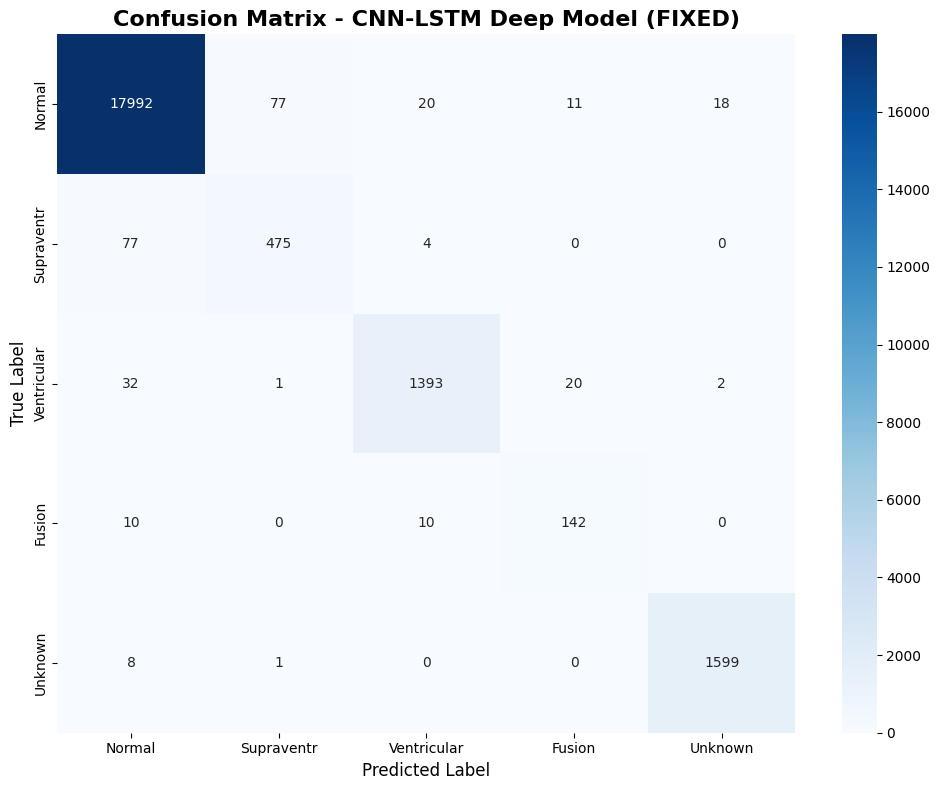

In [ ]:
# ================== 6. TRAINING LOOP ==================
print("\nTraining CNN-LSTM Deep Model WITH NORMALIZATION")
print("=" * 80)

num_epochs = 50
best_f1 = 0.0
patience_counter = 0
patience = 10

train_losses, train_accs, train_f1s = [], [], []
val_losses, val_accs, val_f1s = [], [], []

start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1_macro, val_f1_weighted, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_f1_macro)

    if val_f1_macro > best_f1:
        best_f1 = val_f1_macro
        model_path = os.path.join(models_dir, 'best_model2.pth')
        torch.save(model.state_dict(), model_path)
        patience_counter = 0
    else:
        patience_counter += 1

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)

    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1_macro)

    print(f"Epoch [{epoch + 1:02d}/{num_epochs}]")
    print(f" Train: Loss={train_loss:.4f} | Acc={train_acc:.4f} | F1={train_f1:.4f}")
    print(
        f" Val:   Loss={val_loss:.4f} | Acc={val_acc:.4f} | F1={val_f1_macro:.4f} | F1_weighted={val_f1_weighted:.4f}")
    print()

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1}")
        break

training_time = time.time() - start_time
print(f"Total training time: {training_time:.2f}s ({training_time / 60:.1f} minutes)")

# ================== 6_1. FINAL EVALUATION ==================
print("\n" + "=" * 80)
print("Final Evaluation on Test Set")
print("=" * 80 + "\n")

model_path = os.path.join(models_dir, 'best_model2.pth')
model.load_state_dict(torch.load(model_path))
test_loss, test_acc, test_f1_macro, test_f1_weighted, y_true, y_pred = evaluate(
    model, test_loader, criterion, device)

print(f"Test Results:")
print(f" Accuracy: {test_acc:.4f}")
print(f" F1 (macro): {test_f1_macro:.4f}")
print(f" F1 (weighted): {test_f1_weighted:.4f}")

print("\nPer-class Classification Report:")
print(classification_report(y_true, y_pred,
                            target_names=['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown']))


# ================== 8. VISUALIZATIONS ==================
os.makedirs('results_dir', exist_ok=True)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Supraventr', 'Ventricular', 'Fusion', 'Unknown'],
            yticklabels=['Normal', 'Supraventr', 'Ventricular', 'Fusion', 'Unknown'])
plt.title('Confusion Matrix - CNN-LSTM Deep Model (FIXED)', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=300)
print("\nConfusion matrix saved as 'confusion_matrix.png'")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses, label='Train', linewidth=2, color='blue')
axes[0].plot(val_losses, label='Validation', linewidth=2, color='red')
axes[0].set_title('Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accs, label='Train', linewidth=2, color='blue')
axes[1].plot(val_accs, label='Validation', linewidth=2, color='red')
axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(train_f1s, label='Train', linewidth=2, color='blue')
axes[2].plot(val_f1s, label='Validation', linewidth=2, color='red')
axes[2].set_title('F1 Score (Macro)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('F1 Score', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=300)
print("Training curves saved as 'training_curves.png'")

print("\nTraining completed.")
print(f"Best validation F1 (macro): {best_f1:.4f}")
print(f"Model saved to: {model_path}")
print(f"Scaler saved to: {scaler_path}")

cm_path = os.path.join(results_dir, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=300)
print(f"\nConfusion matrix saved as '{cm_path}'")

curves_path = os.path.join(results_dir, 'training_curves.png')
plt.savefig(curves_path, dpi=300)
print(f"Training curves saved as '{curves_path}'")